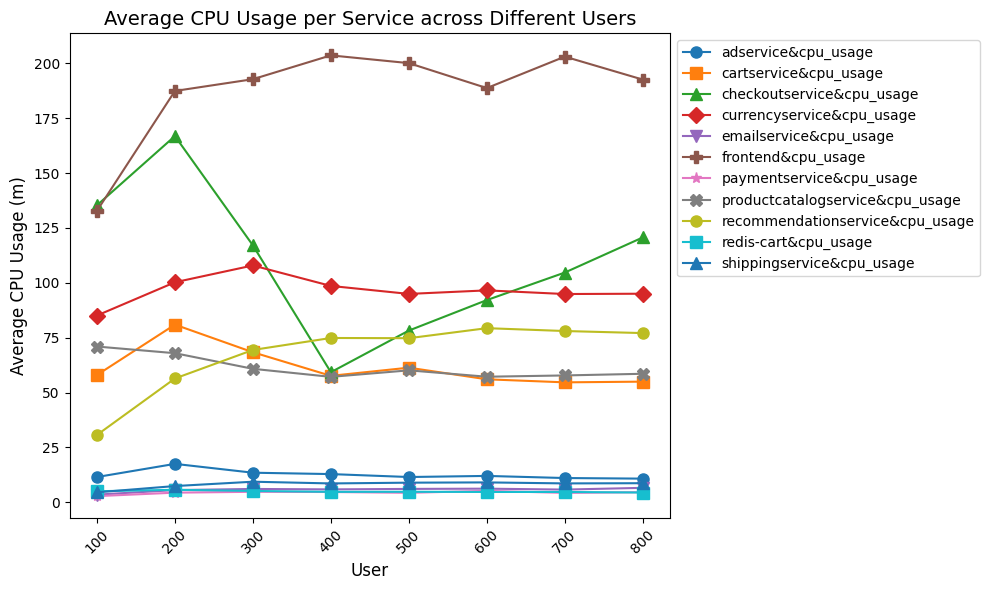

In [ ]:
# 导入必要的库
import pandas as pd
import matplotlib.pyplot as plt
import os

users_num = 8
# 创建一个函数来计算每个服务的平均值
def compute_average(df):
    # 计算每个服务列的平均值 (排除'timestamp'列)
    services = df.columns[1:]  # 忽略'timestamp'列
    avg_values = df[services].mean()
    return avg_values

# 定义文件路径列表
files = [f"svc_metric{(i+1)*100}.csv" for i in range(users_num)]
# 初始化一个字典来保存每个文件每个服务的平均 CPU 使用率
averages = {file: [] for file in files}
metrics_dir = './svc_metrics'
# 读取每个 CSV 文件并计算平均值
for file in files:
    # 读取数据
    path = os.path.join(metrics_dir, file)
    df = pd.read_csv(path)
    
    # 计算每个服务的平均值
    avg_values = compute_average(df) * 1000
    
    # 将计算结果保存到字典中
    averages[file] = avg_values

# 将字典转换为 DataFrame 方便绘图
avg_df = pd.DataFrame(averages).T  # 转置，使文件名成为行，服务名成为列
xticks = range(100, 801, 100)
# 定义不同的标记形状
markers = ['o', 's', '^', 'D', 'v', 'P', '*', 'X']  # 你可以根据需要调整这些标记
# 绘制每个微服务的 CPU 使用率变化折线图
plt.figure(figsize=(10, 6))

# 为每个服务绘制一条折线
for i, service in enumerate(avg_df.columns):
    plt.plot(xticks, avg_df[service], label=service, marker=markers[i % len(markers)], markersize=8)

# 添加标题和标签
plt.title("Average CPU Usage per Service across Different Users", fontsize=14)
plt.xlabel("User", fontsize=12)
plt.ylabel("Average CPU Usage (m)", fontsize=12)
plt.xticks(rotation=45)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

# 显示图形
plt.tight_layout()
plt.show()

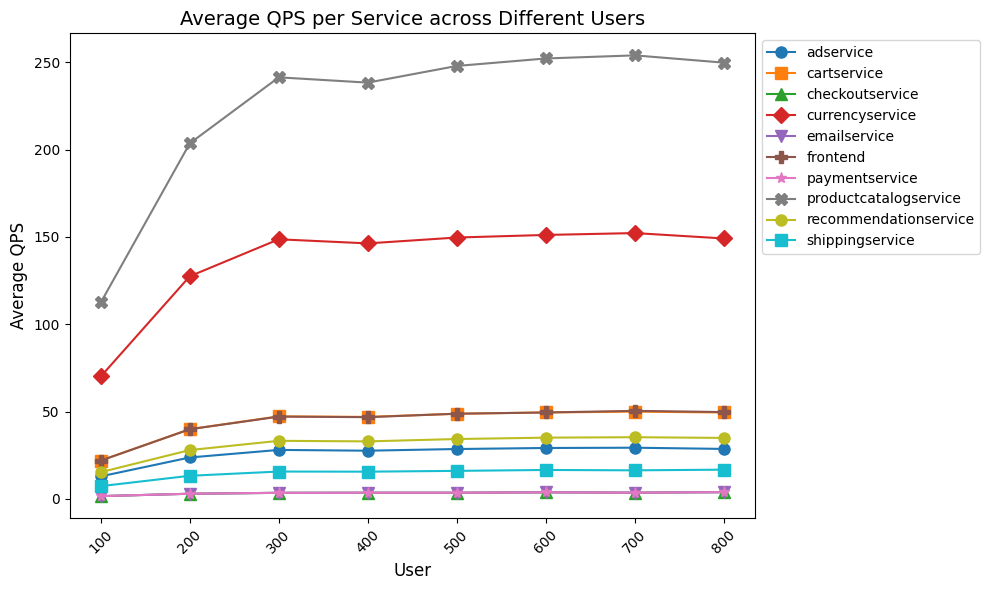

In [ ]:
# 初始化一个列表来保存每个文件的平均值
averages = []
qps_dir = './svc_qps'
for i in range(users_num):  # 假设文件名为0.csv到7.csv
    file_path = f'svc_qps{(i+1)*100}.csv'  # 文件路径
    path = os.path.join(qps_dir, file_path)
    df = pd.read_csv(path)
    # 计算平均值并添加到averages列表
    avg_values = compute_average(df)
    averages.append(avg_values)

# 将平均值转换为DataFrame，方便绘图
avg_df = pd.DataFrame(averages)
# 绘制每个服务在不同文件中的平均值变化折线图
plt.figure(figsize=(10, 6))

# 为每个服务绘制折线图
for i, service in enumerate(avg_df.columns):
    plt.plot(xticks, avg_df[service], label=service, marker=markers[i % len(markers)], markersize=8)

# 添加标题和标签
plt.title('Average QPS per Service across Different Users', fontsize=14)
plt.xlabel('User', fontsize=12)
plt.ylabel('Average QPS', fontsize=12)
plt.xticks(rotation=45)  # 设置 x 轴为文件名
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')

# 显示图形
plt.tight_layout()
plt.show()

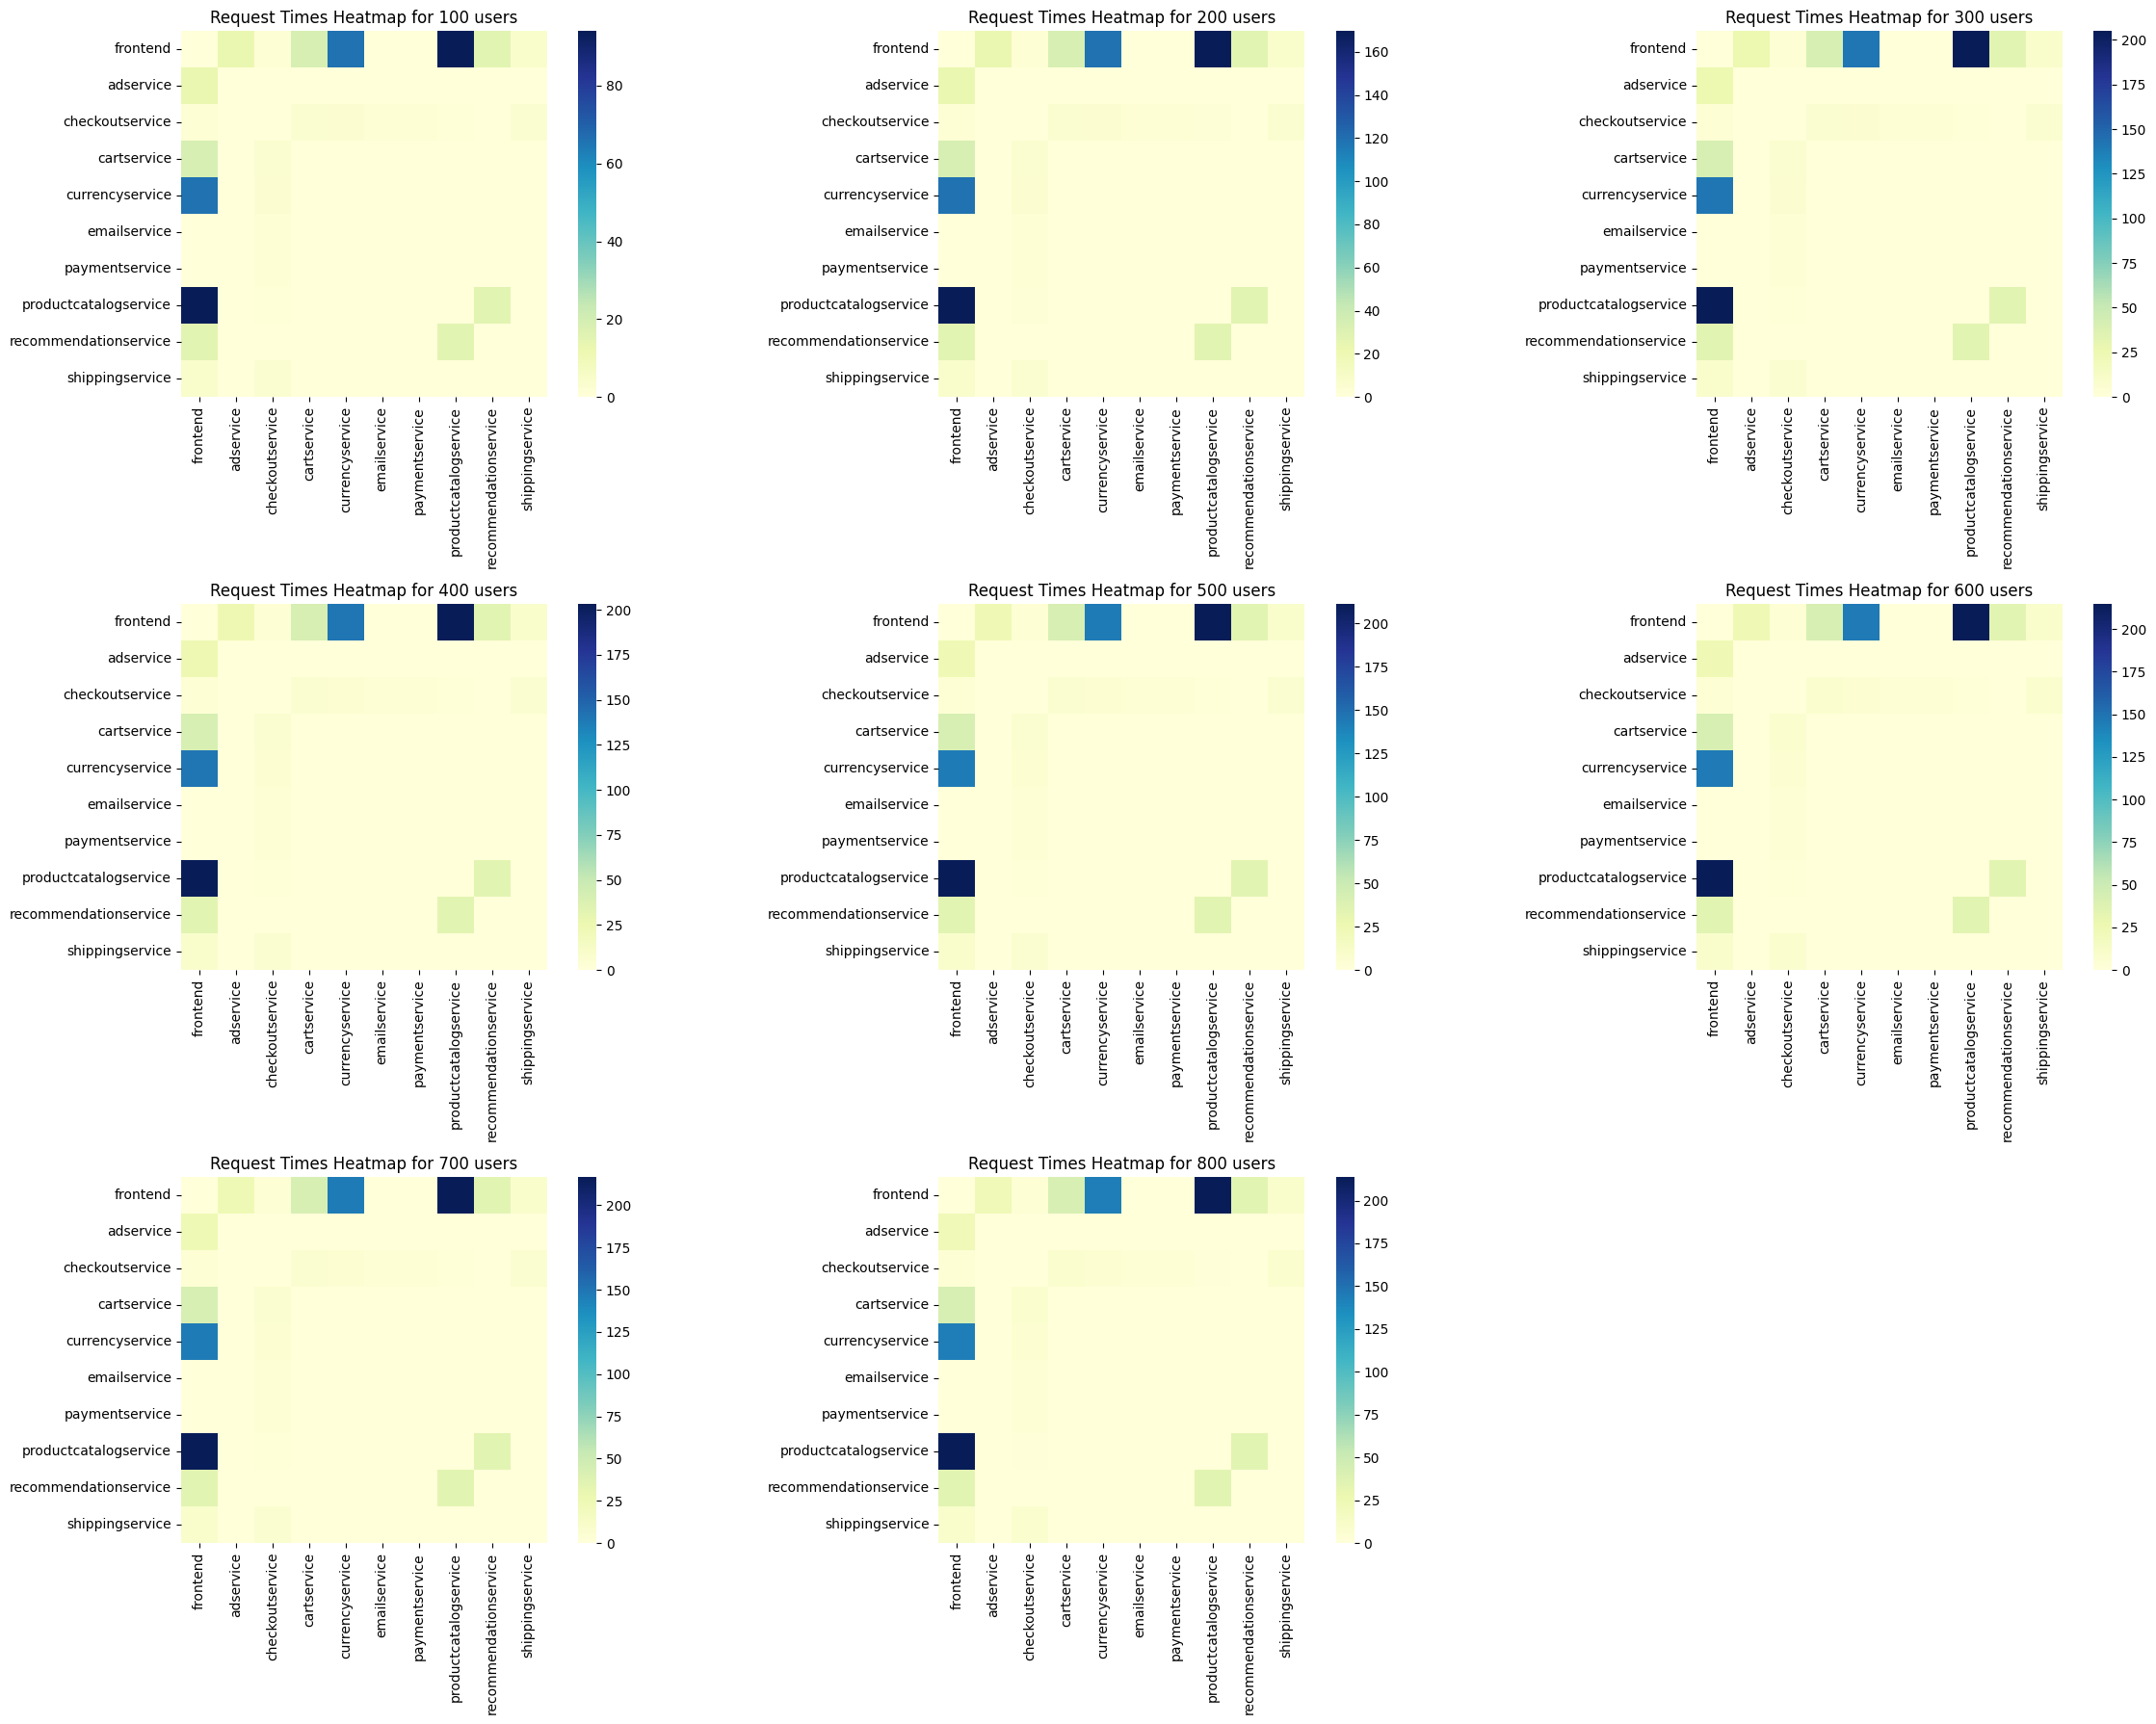

In [ ]:
import seaborn as sns


# 设置绘图的行列数，可以根据需要调整
num_rows = 3  
num_cols = 3  
request_dir = './request_times'
# 创建一个图形，包含多个子图
plt.figure(figsize=(24, 18))
for i in range(users_num):
    file_path = f'request_times{(i+1)*100}.csv'  # 文件路径
    csv_file = os.path.join(request_dir, file_path)
    # 加载 CSV 数据
    df = pd.read_csv(csv_file)
    # 提取微服务对的名称
    service_pairs = [col.split('_') for col in df.columns[1:]]  # 假设第一列是时间戳或其他非服务数据

    # 计算每列的平均值
    average_call_counts = df.iloc[:, 1:].mean()  # 计算所有列（即微服务对）的平均值

    # 初始化一个字典，用于存储每对微服务的平均调用次数
    service_pair_avg_counts = {}

    # 填充字典
    for j, pair in enumerate(service_pairs):
        service1, service2 = pair
        avg_count = average_call_counts[j]  # 获取每列的平均值
        
        # 存储每对微服务的平均调用次数
        if service1 not in service_pair_avg_counts:
            service_pair_avg_counts[service1] = {}
        service_pair_avg_counts[service1][service2] = avg_count

        # 确保 service1 <-> service2 和 service2 <-> service1 是一样的
        if service2 not in service_pair_avg_counts:
            service_pair_avg_counts[service2] = {}
        service_pair_avg_counts[service2][service1] = avg_count

    # 获取所有微服务的名称
    services = list(service_pair_avg_counts.keys())
    heatmap_data = pd.DataFrame(index=services, columns=services)

    # 填充热力图数据
    for service1 in services:
        for service2 in services:
            if service2 in service_pair_avg_counts[service1]:
                avg_count = service_pair_avg_counts[service1][service2]
                heatmap_data.loc[service1, service2] = avg_count
            else:
                heatmap_data.loc[service1, service2] = 0

    # 添加一个子图
    plt.subplot(num_rows, num_cols, i + 1)
    sns.heatmap(heatmap_data.astype(float), annot=False, cmap='YlGnBu', fmt='.2f', cbar=True, square=True)

    # 设置标题
    plt.title(f'Request Times Heatmap for {(i+1)*100} users')
    # 调整坐标轴标签的字体大小和旋转
    plt.xticks(fontsize=10)  # X轴标签旋转45度，字体大小10
    plt.yticks(fontsize=10)  # Y轴标签旋转45度，字体大小10

# 调整布局，防止图表重叠
# plt.subplots_adjust(hspace=0.5, wspace=0.5)
plt.tight_layout()
# 显示图形
plt.show()


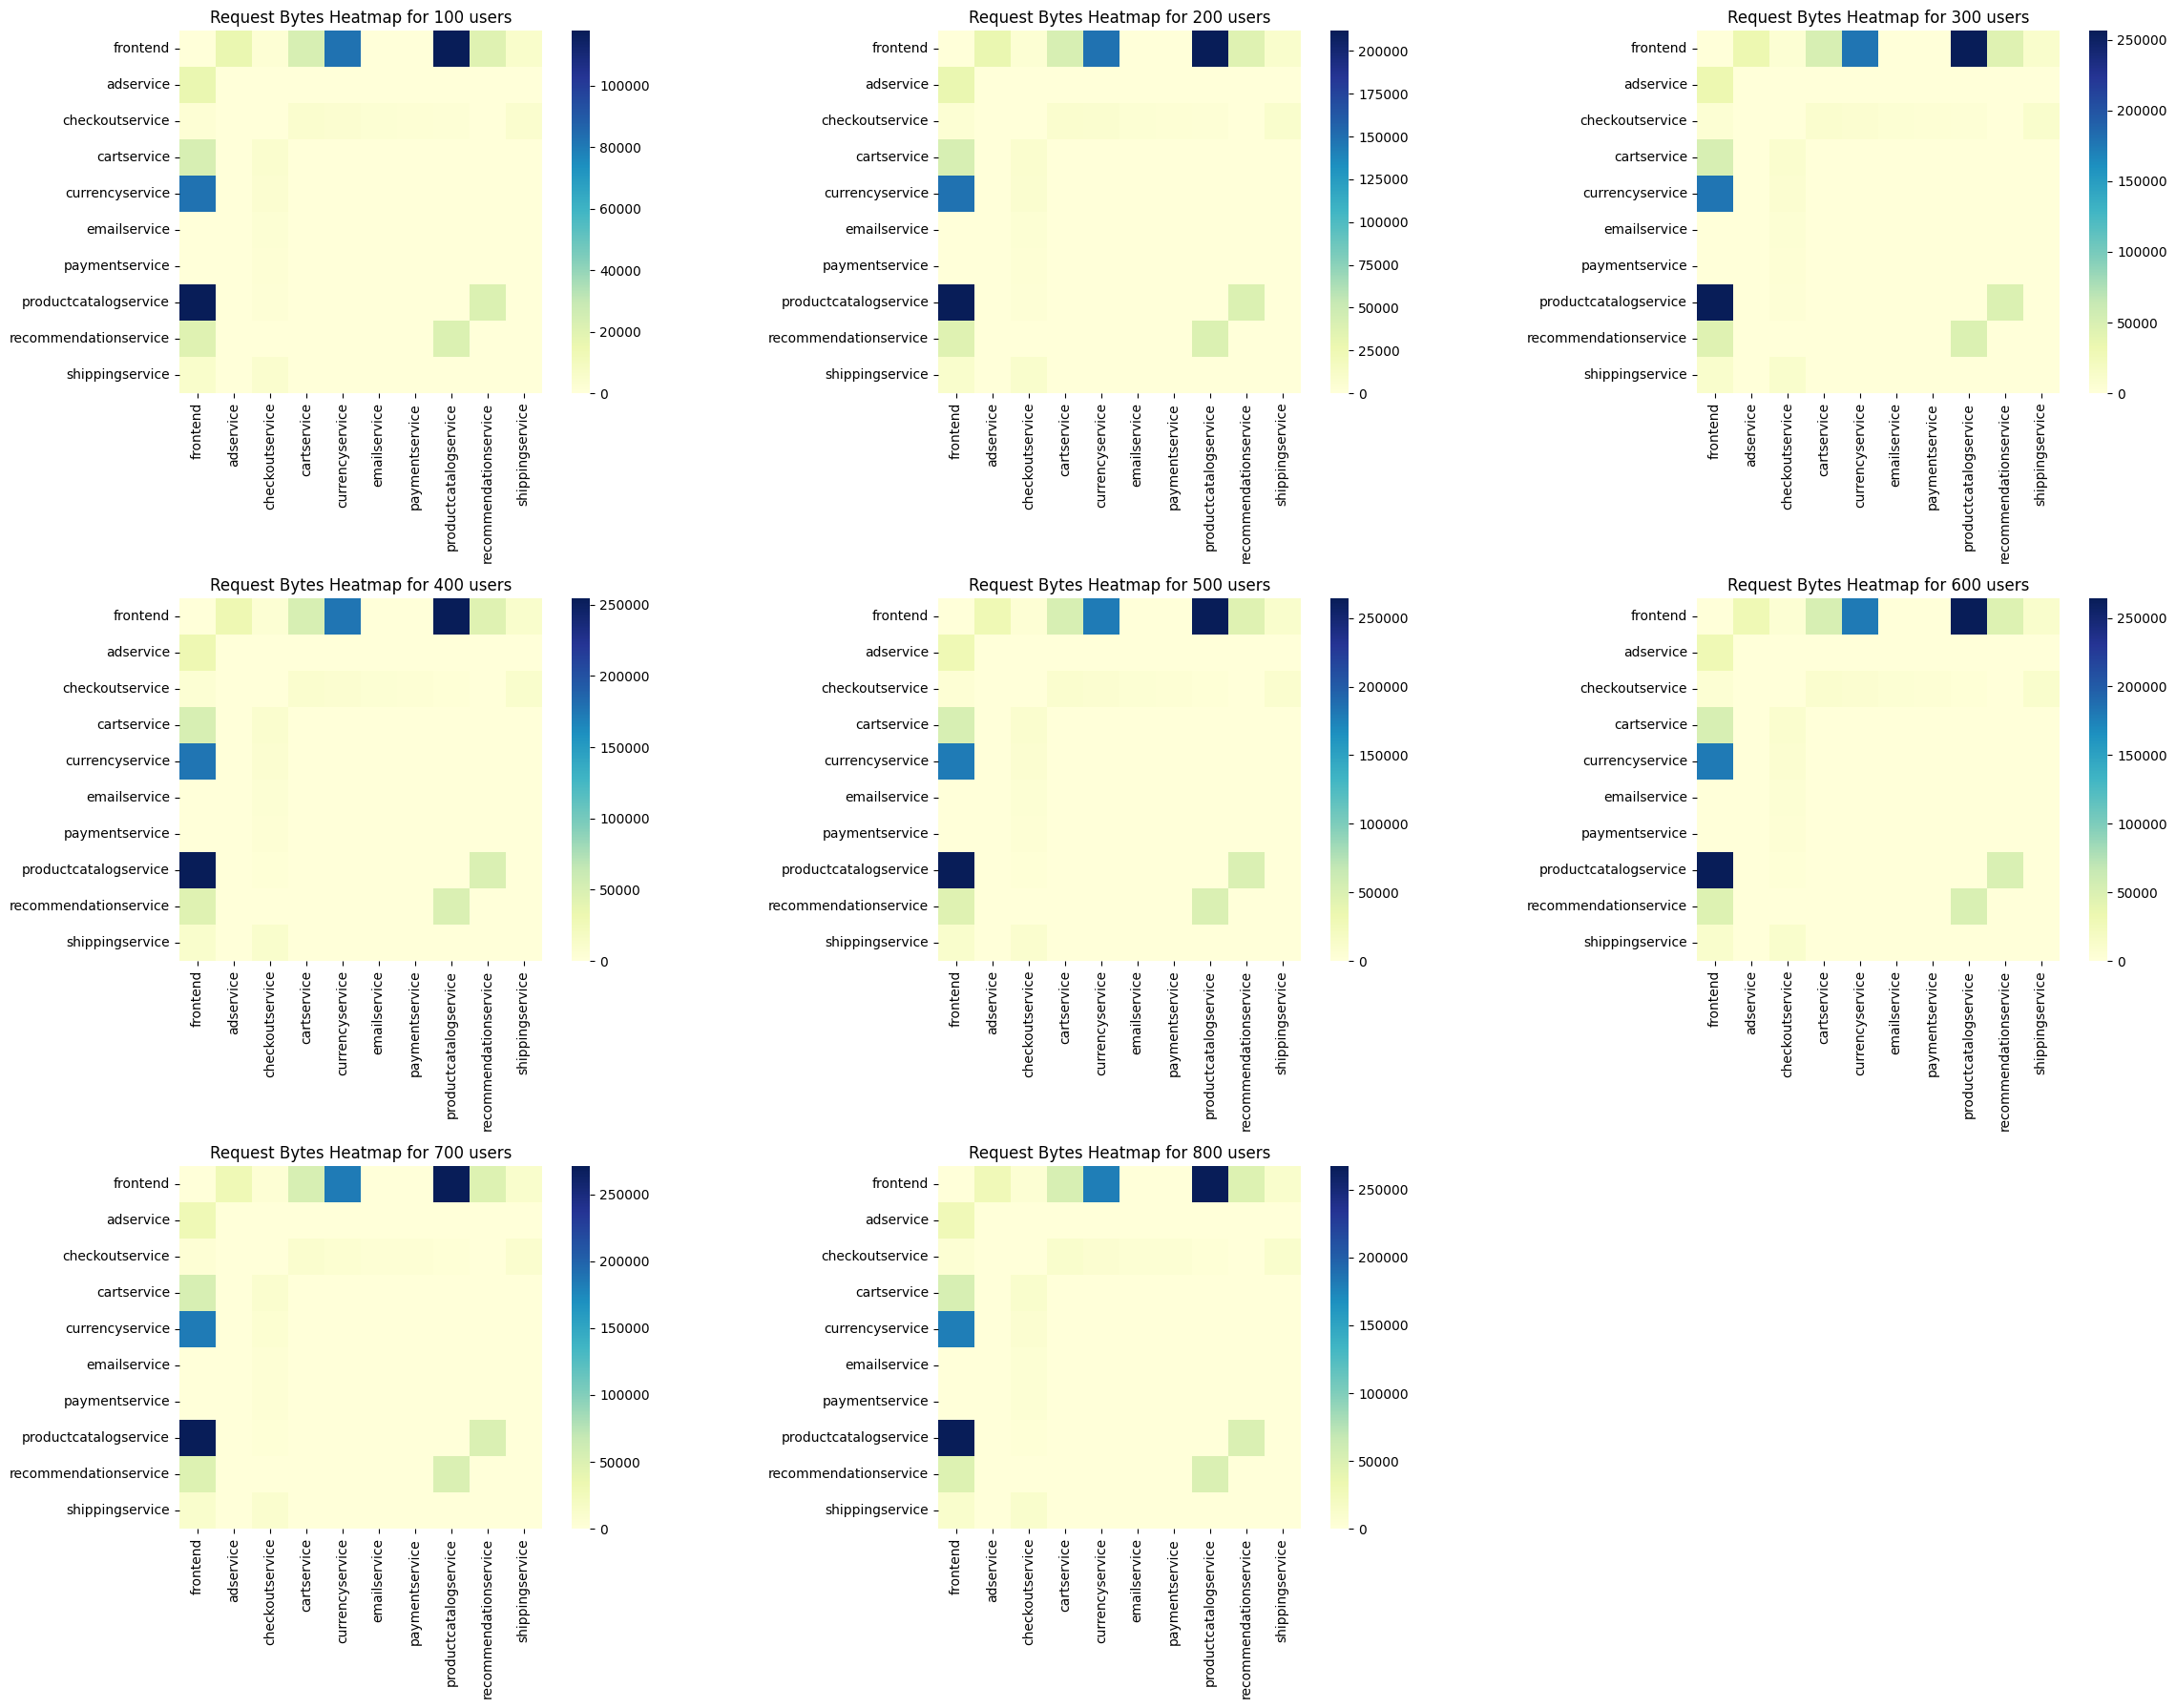

In [ ]:
# 设置绘图的行列数，可以根据需要调整
num_rows = 3  
num_cols = 3  
request_dir = './request_bytes'
# 创建一个图形，包含多个子图
plt.figure(figsize=(24, 18))
for i in range(users_num):
    file_path = f'request_bytes{(i+1)*100}.csv'  # 文件路径
    csv_file = os.path.join(request_dir, file_path)
    # 加载 CSV 数据
    df = pd.read_csv(csv_file)
    # 提取微服务对的名称
    service_pairs = [col.split('_') for col in df.columns[1:]]  # 假设第一列是时间戳或其他非服务数据

    # 计算每列的平均值
    average_call_counts = df.iloc[:, 1:].mean()  # 计算所有列（即微服务对）的平均值

    # 初始化一个字典，用于存储每对微服务的平均调用次数
    service_pair_avg_counts = {}

    # 填充字典
    for j, pair in enumerate(service_pairs):
        service1, service2 = pair
        avg_count = average_call_counts[j]  # 获取每列的平均值
        
        # 存储每对微服务的平均调用次数
        if service1 not in service_pair_avg_counts:
            service_pair_avg_counts[service1] = {}
        service_pair_avg_counts[service1][service2] = avg_count

        # 确保 service1 <-> service2 和 service2 <-> service1 是一样的
        if service2 not in service_pair_avg_counts:
            service_pair_avg_counts[service2] = {}
        service_pair_avg_counts[service2][service1] = avg_count

    # 获取所有微服务的名称
    services = list(service_pair_avg_counts.keys())
    heatmap_data = pd.DataFrame(index=services, columns=services)

    # 填充热力图数据
    for service1 in services:
        for service2 in services:
            if service2 in service_pair_avg_counts[service1]:
                avg_count = service_pair_avg_counts[service1][service2]
                heatmap_data.loc[service1, service2] = avg_count
            else:
                heatmap_data.loc[service1, service2] = 0

    # 添加一个子图
    plt.subplot(num_rows, num_cols, i + 1)
    sns.heatmap(heatmap_data.astype(float), annot=False, cmap='YlGnBu', fmt='.2f', cbar=True, square=True)

    # 设置标题
    plt.title(f'Request Bytes Heatmap for {(i+1)*100} users')
    # 调整坐标轴标签的字体大小和旋转
    plt.xticks(fontsize=10)  # X轴标签旋转45度，字体大小10
    plt.yticks(fontsize=10)  # Y轴标签旋转45度，字体大小10

# 调整布局，防止图表重叠
# plt.subplots_adjust(hspace=0.5, wspace=0.5)
plt.tight_layout()
# 显示图形
plt.show()


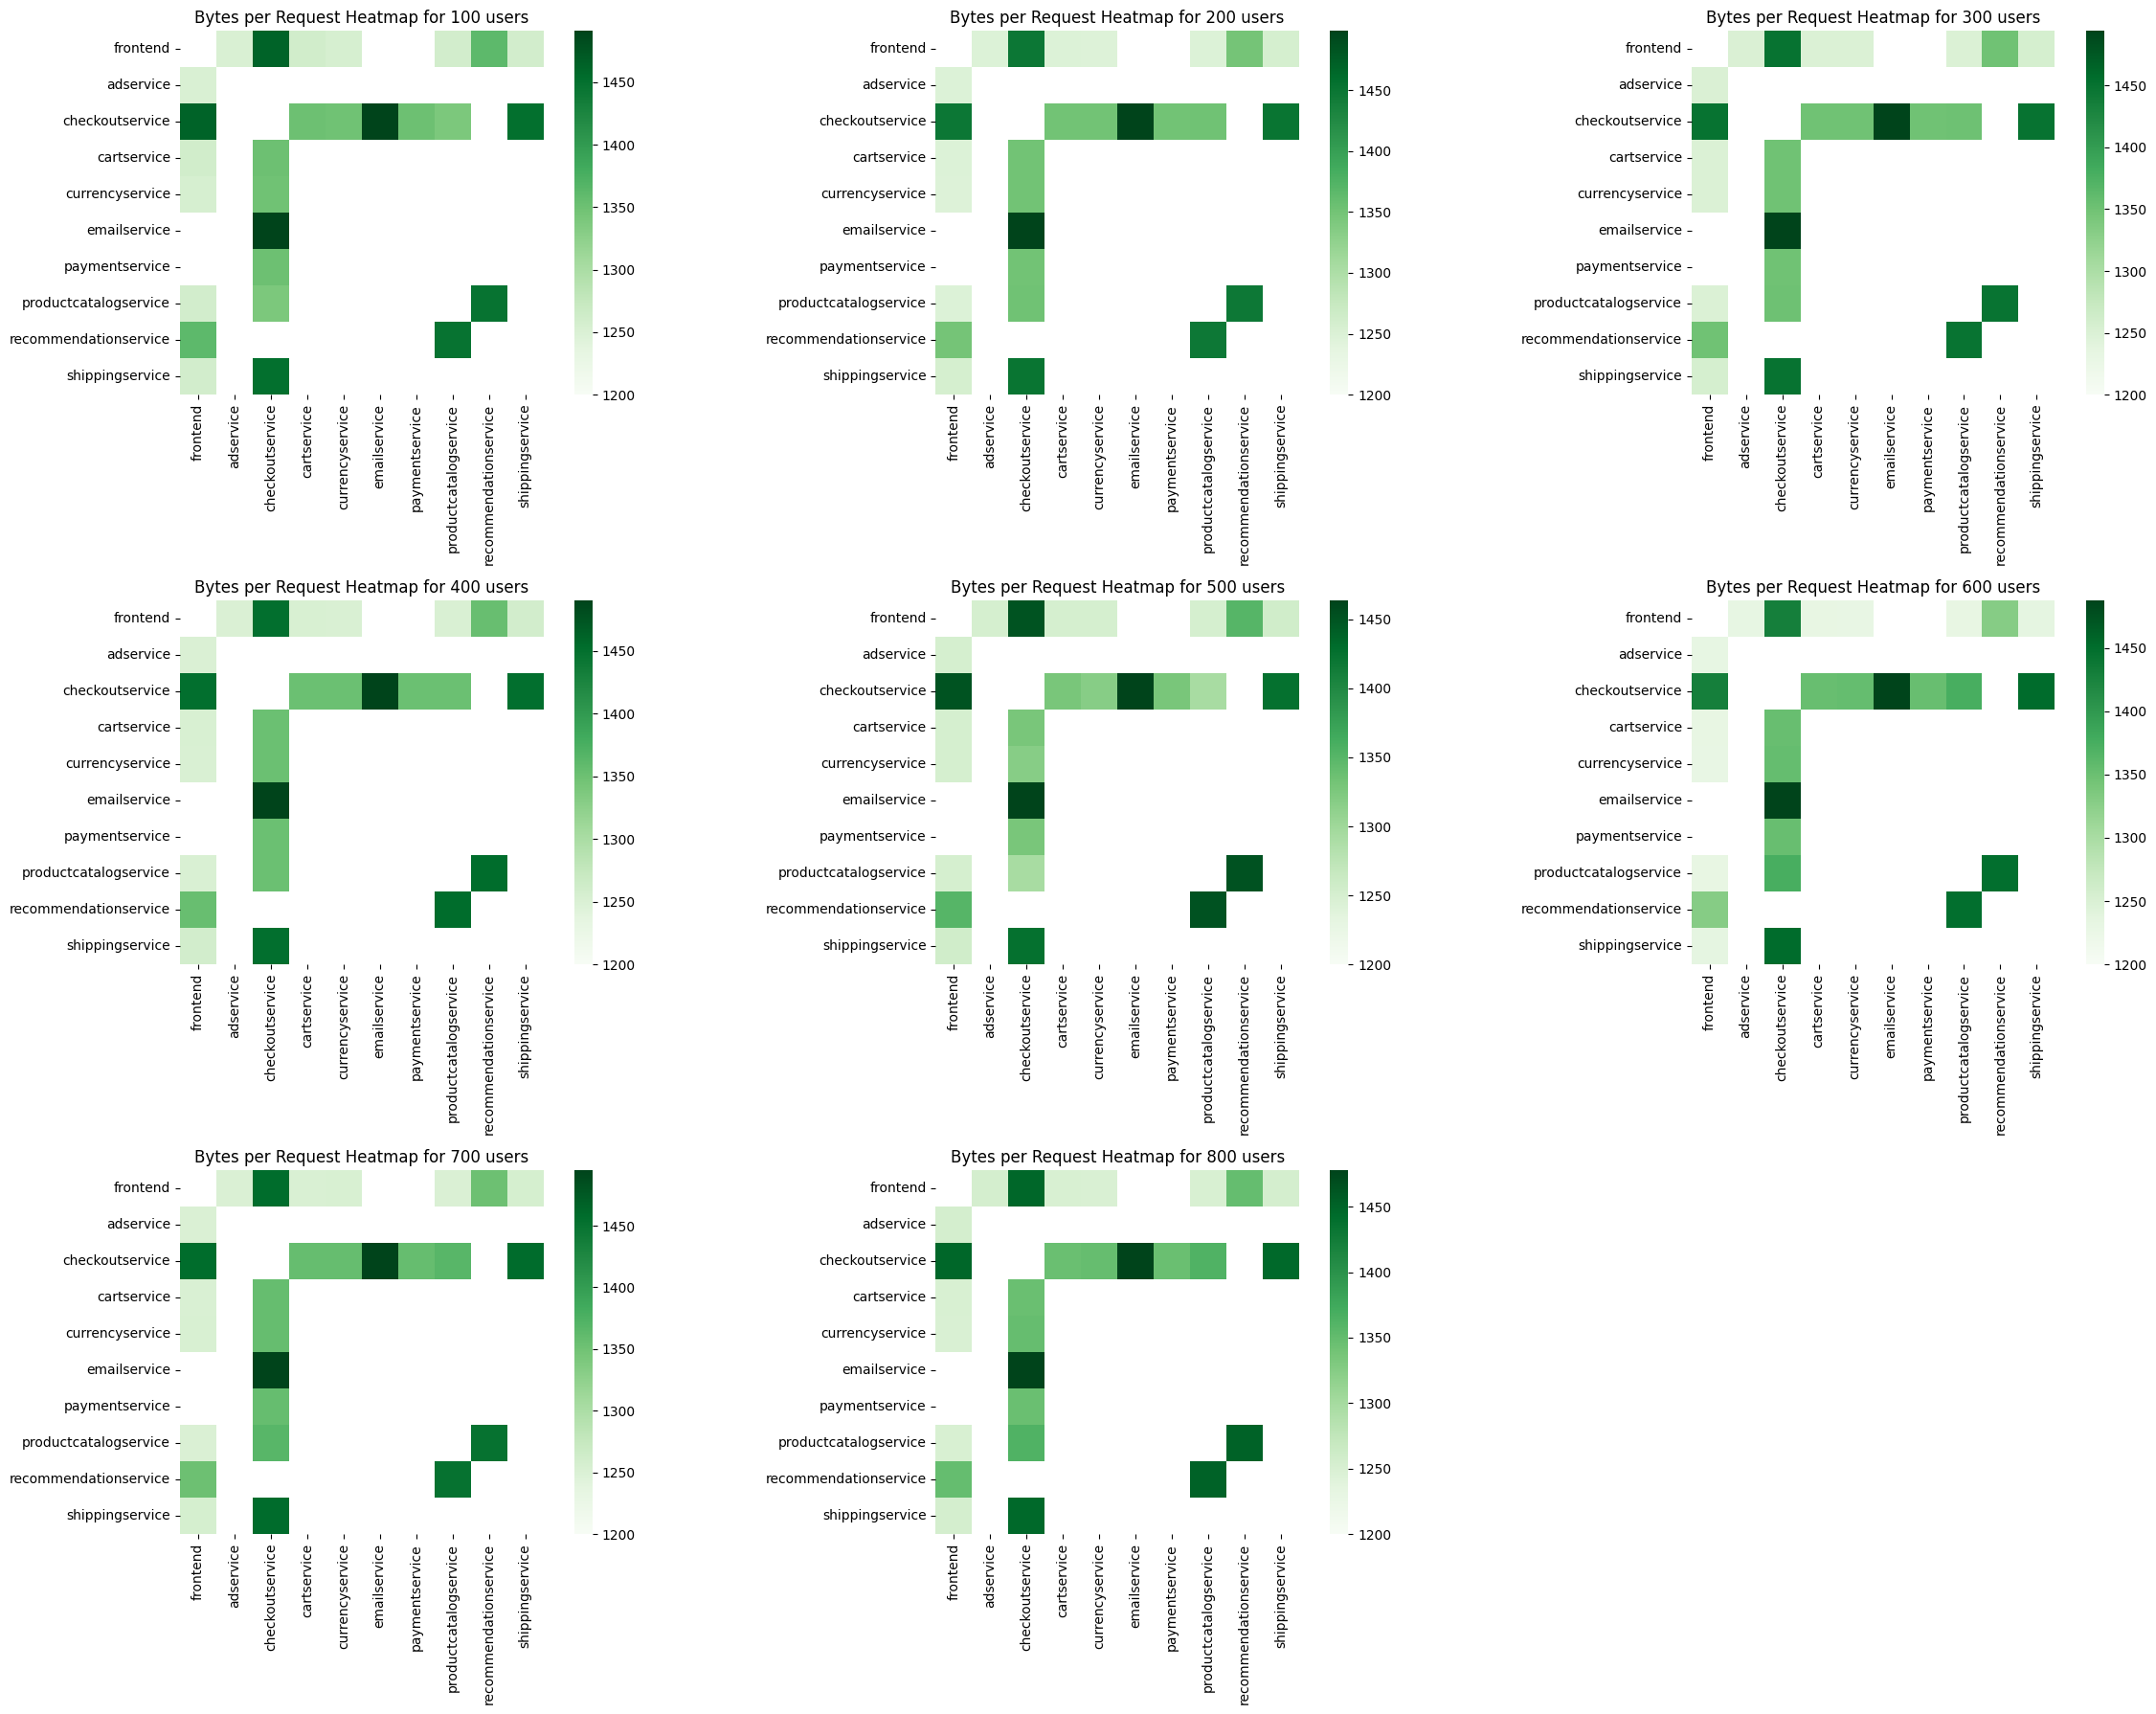

In [ ]:
# 设置绘图的行列数，可以根据需要调整
num_rows = 3  
num_cols = 3  
request_dir = './per_request_bytes'
# 创建一个图形，包含多个子图
plt.figure(figsize=(24, 18))
for i in range(users_num):
    file_path = f'per_request_bytes{(i+1)*100}.csv'  # 文件路径
    csv_file = os.path.join(request_dir, file_path)
    # 加载 CSV 数据
    df = pd.read_csv(csv_file)
    # 提取微服务对的名称
    service_pairs = [col.split('_') for col in df.columns[1:]]  # 假设第一列是时间戳或其他非服务数据

    # 计算每列的平均值
    average_call_counts = df.iloc[:, 1:].mean()  # 计算所有列（即微服务对）的平均值

    # 初始化一个字典，用于存储每对微服务的平均调用次数
    service_pair_avg_counts = {}

    # 填充字典
    for j, pair in enumerate(service_pairs):
        service1, service2 = pair
        avg_count = average_call_counts[j]  # 获取每列的平均值
        
        # 存储每对微服务的平均调用次数
        if service1 not in service_pair_avg_counts:
            service_pair_avg_counts[service1] = {}
        service_pair_avg_counts[service1][service2] = avg_count

        # 确保 service1 <-> service2 和 service2 <-> service1 是一样的
        if service2 not in service_pair_avg_counts:
            service_pair_avg_counts[service2] = {}
        service_pair_avg_counts[service2][service1] = avg_count

    # 获取所有微服务的名称
    services = list(service_pair_avg_counts.keys())
    heatmap_data = pd.DataFrame(index=services, columns=services)

    # 填充热力图数据
    for service1 in services:
        for service2 in services:
            if service2 in service_pair_avg_counts[service1]:
                avg_count = service_pair_avg_counts[service1][service2]
                heatmap_data.loc[service1, service2] = avg_count
            else:
                heatmap_data.loc[service1, service2] = 0

    # 设置绿色渐变色
    green_cmap = sns.light_palette("green", as_cmap=True)  # 绿色渐变色

    # 创建一个 mask，0 的位置不显示颜色
    mask = heatmap_data == 0
    # 添加一个子图
    plt.subplot(num_rows, num_cols, i + 1)
    sns.heatmap(heatmap_data.astype(float), annot=False, cmap='Greens', fmt='.2f', cbar=True, square=True, mask=mask, vmin=1200)

    # 设置标题
    plt.title(f'Bytes per Request Heatmap for {(i+1)*100} users')
    # 调整坐标轴标签的字体大小和旋转
    plt.xticks(fontsize=10)  # X轴标签旋转45度，字体大小10
    plt.yticks(fontsize=10)  # Y轴标签旋转45度，字体大小10

# 调整布局，防止图表重叠
# plt.subplots_adjust(hspace=0.5, wspace=0.5)
plt.tight_layout()
# 显示图形
plt.show()

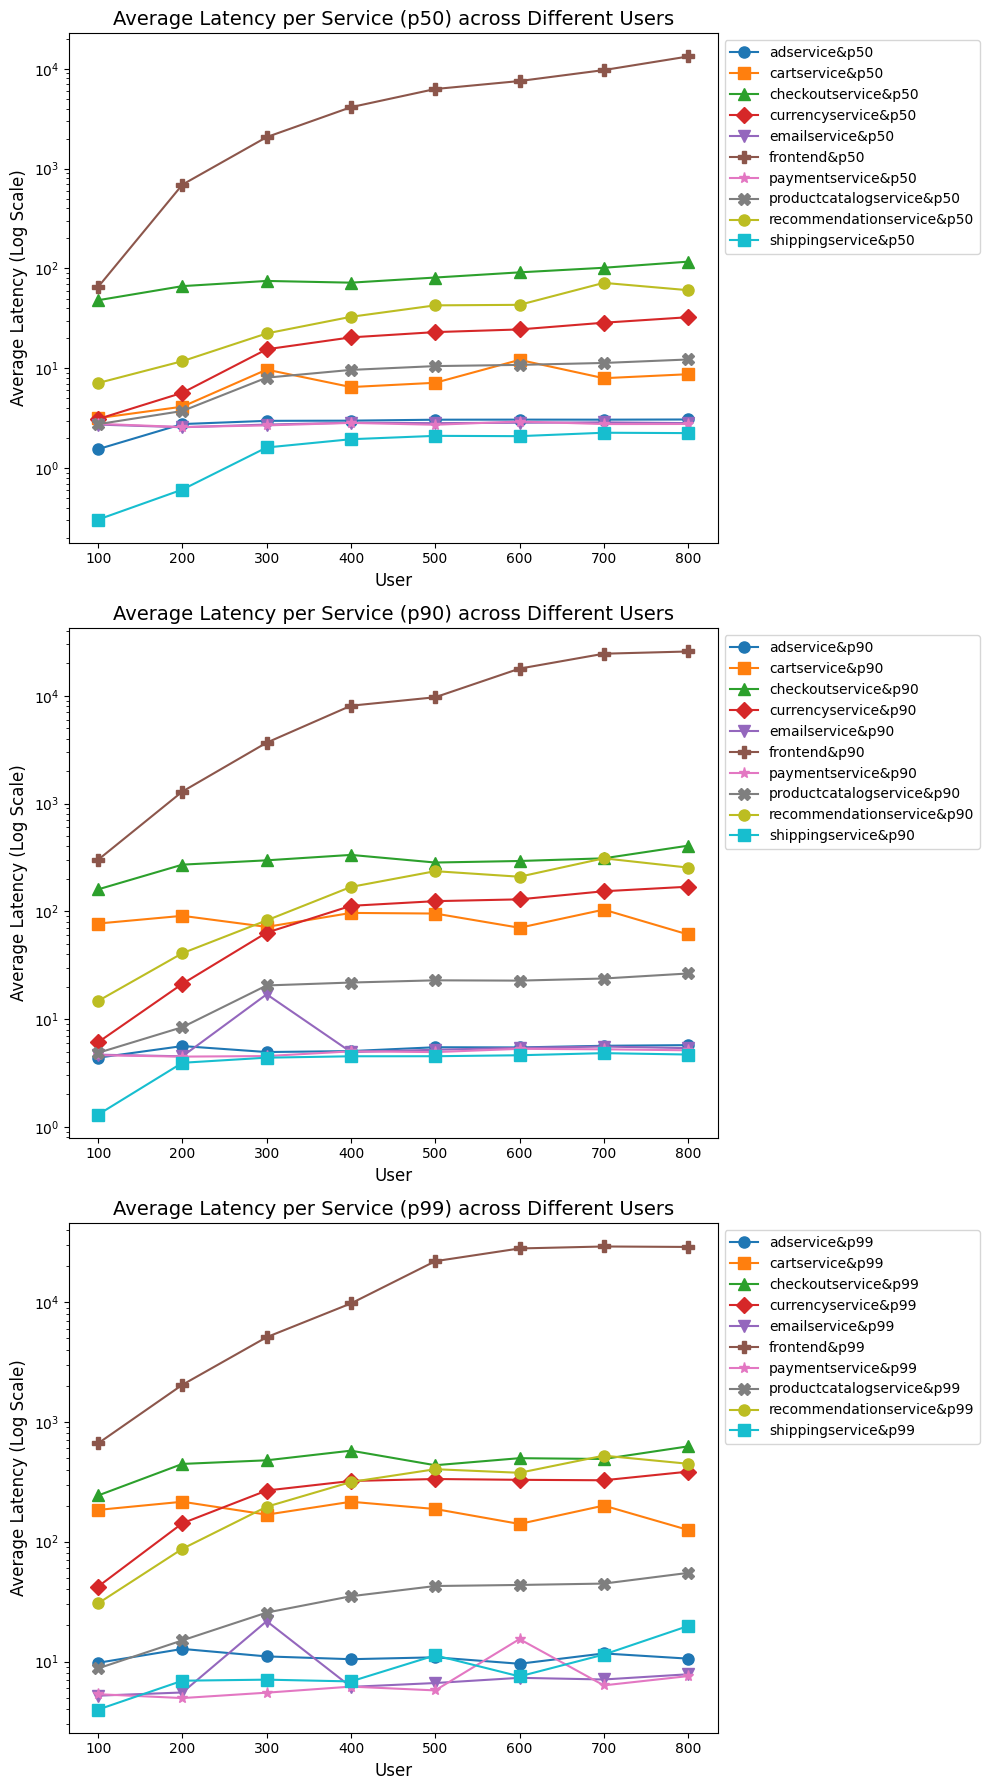

In [ ]:
def compute_average(df, suffix):
    # 选择包含后缀的列（例如 'adservice&p50' 等）
    services = [col for col in df.columns if col.endswith(suffix)]  
    avg_values = df[services].mean()
    return avg_values

# 初始化一个列表来保存每个文件的平均值
averages_p50 = []
averages_p9 = []
averages_p99 = []
qps_dir = './latency'

for i in range(users_num):  # 假设文件名为0.csv到7.csv
    file_path = f'latency{(i+1)*100}.csv'  # 文件路径
    path = os.path.join(qps_dir, file_path)
    df = pd.read_csv(path)
    
    # 计算每个后缀的平均值并添加到相应的列表
    avg_p50 = compute_average(df, 'p50')
    averages_p50.append(avg_p50)
    
    avg_p9 = compute_average(df, 'p90')
    averages_p9.append(avg_p9)
    
    avg_p99 = compute_average(df, 'p99')
    averages_p99.append(avg_p99)

# 将平均值转换为DataFrame，方便绘图
avg_df_p50 = pd.DataFrame(averages_p50)
avg_df_p9 = pd.DataFrame(averages_p9)
avg_df_p99 = pd.DataFrame(averages_p99)

xticks = range(100, 801, 100)
markers = ['o', 's', '^', 'D', 'v', 'P', '*', 'X']  # 可以根据需要调整这些标记

# 绘制 p50、p9 和 p99 的三个图
fig, axes = plt.subplots(3, 1, figsize=(10, 18))

# p50 图
axes[0].set_title('Average Latency per Service (p50) across Different Users', fontsize=14)
for i, service in enumerate(avg_df_p50.columns):
    axes[0].plot(xticks, avg_df_p50[service], label=service, marker=markers[i % len(markers)], markersize=8)
axes[0].set_xlabel('User', fontsize=12)
axes[0].set_ylabel('Average Latency (Log Scale)', fontsize=12)
axes[0].set_yscale('log')
axes[0].legend(bbox_to_anchor=(1, 1), loc='upper left')

# p9 图
axes[1].set_title('Average Latency per Service (p90) across Different Users', fontsize=14)
for i, service in enumerate(avg_df_p9.columns):
    axes[1].plot(xticks, avg_df_p9[service], label=service, marker=markers[i % len(markers)], markersize=8)
axes[1].set_xlabel('User', fontsize=12)
axes[1].set_ylabel('Average Latency (Log Scale)', fontsize=12)
axes[1].set_yscale('log')
axes[1].legend(bbox_to_anchor=(1, 1), loc='upper left')

# p99 图
axes[2].set_title('Average Latency per Service (p99) across Different Users', fontsize=14)
for i, service in enumerate(avg_df_p99.columns):
    axes[2].plot(xticks, avg_df_p99[service], label=service, marker=markers[i % len(markers)], markersize=8)
axes[2].set_xlabel('User', fontsize=12)
axes[2].set_ylabel('Average Latency (Log Scale)', fontsize=12)
axes[2].set_yscale('log')
axes[2].legend(bbox_to_anchor=(1, 1), loc='upper left')

# 显示图形
plt.tight_layout()
plt.show()